<a href="https://colab.research.google.com/github/LeninGF/IAG-2024B-GenerativeQA/blob/main/dataset_build.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset

- Coder: Lenin G. Falconi

## Goal:

- To format dataset in question, answer and context
- To use some LLM in order to retrieve or build questions from the data



In [1]:
# For Colab
!pip install python-dotenv
!pip install huggingface_hub
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 13.8 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.5.1+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.5.1+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system 

In [5]:
# For Colab
from dotenv import load_dotenv
import os
dotenv_path = '/content/.env'
load_dotenv(dotenv_path)

True

In [6]:
import os
from huggingface_hub import login
token = os.getenv('HUGGINGFACE_TOKEN')
login(token)

In [7]:
from datasets import load_dataset
dataset_path = 'LeninGF/autotrain-data-robberyclassification'
# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset(dataset_path)

trainsethugf.csv:   0%|          | 0.00/195M [00:00<?, ?B/s]

validsethugf.csv:   0%|          | 0.00/48.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/341669 [00:00<?, ? examples/s]

In [8]:
from pprint import pprint
pprint(ds['train'][100])

{'labels': 'ROBO A DOMICILIO',
 'relato': 'es el caso señor fiscal que el día 17 de agosto del 2018 '
           'aproximadamente a las 11h00 salí de mi domicilio ubicado en la '
           'cooperativa 8 de marzo calle n pasaje e20j lote 3 número s8 45 '
           'sector puente dos autopista general rumiñahui a realizar una '
           'gestión de pagos al retornar a las 13h20 pude observar que tres '
           'sujetos salían de mi domicilio y afuera ase encontraba estacionado '
           'un automóvil al ingresar me percate que me habías sustraído dos '
           'televisores marca lg 4k de 65 pulgadas un televisor marca samsung '
           'hd de 32 pulgadas un play station pro 1tb un nintendo switch '
           'cuatro whisky un lote de joyas de plata y oro valorado en 3 450 '
           'dolares y 40 dólares en efectivo motivo por la cual pongo la '
           'respectiva denuncia con la finalidad de que se realicen las '
           'investigaciones del caso más informaci

## Word count per Text Histogram

In [9]:
def count_words(sample):
    sample['word_count'] = len(sample['relato'].split())
    return sample

ds = ds.map(count_words, batched=False)

Map:   0%|          | 0/341669 [00:00<?, ? examples/s]

In [10]:
pprint(ds['train'][10002])

{'labels': 'ROBO DE MOTOS',
 'relato': 'es el caso señor fiscal que el día 19 de diciembre de 2016 siendo '
           'aproximadamente las 07h20 en circunstancias que conducía la '
           'motocicleta marca daytona modelo dy200 shark ii color rojo de '
           'placa hz849b esperaba cambio de luz del semáforo en las calles '
           '11ava y 4 de noviembre cuando se acercó otra motocicleta marca '
           'suzuki x100 con dos individuos uno de ellos se bajó con arma de '
           'fuego dijo bájate no digas nada acto seguido se sustrajeron la '
           'motocicleta antes mencionada',
 'word_count': 81}


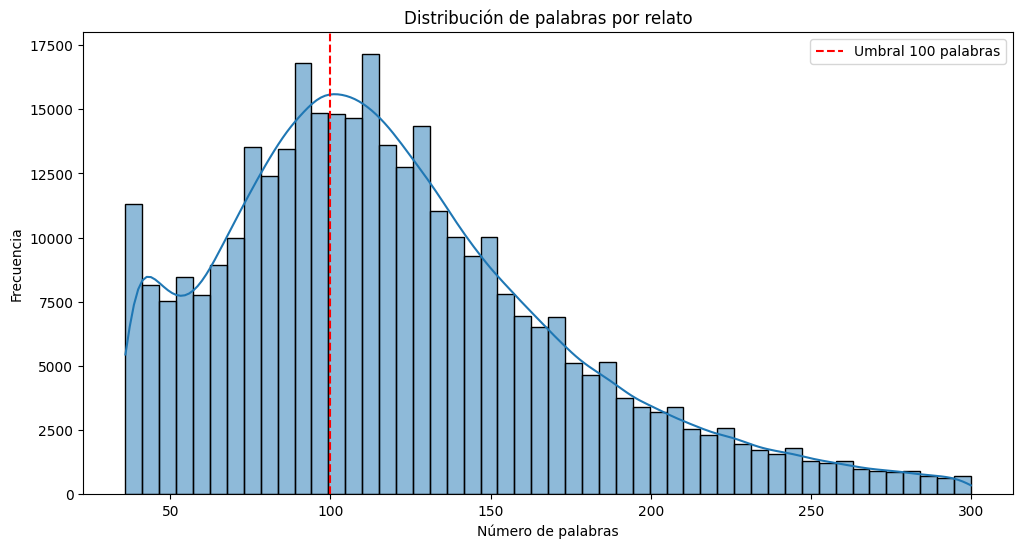

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear histograma
plt.figure(figsize=(12, 6))
sns.histplot(ds["train"]["word_count"], bins=50, kde=True)
plt.title("Distribución de palabras por relato")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.axvline(x=100, color="r", linestyle="--", label="Umbral 100 palabras")
plt.legend()
plt.show()

In [12]:
import numpy as np

# Extraer la lista de word_counts directamente desde el Dataset
word_counts = np.array(ds["train"]["word_count"])  # Se carga como array de numpy (eficiente en memoria)

# Calcular estadísticas
stats = {
    "count": len(word_counts),
    "mean": np.mean(word_counts).round(2),
    "std": np.std(word_counts).round(2),
    "min": np.min(word_counts),
    "25%": np.percentile(word_counts, 25).round(2),
    "50%": np.median(word_counts).round(2),
    "75%": np.percentile(word_counts, 75).round(2),
    "max": np.max(word_counts),
}

# Imprimir resultados
print("Estadísticas de word_count:")
for key, value in stats.items():
    print(f"{key}: {value}")

Estadísticas de word_count:
count: 341669
mean: 120.4
std: 53.24
min: 36
25%: 82.0
50%: 112.0
75%: 150.0
max: 300


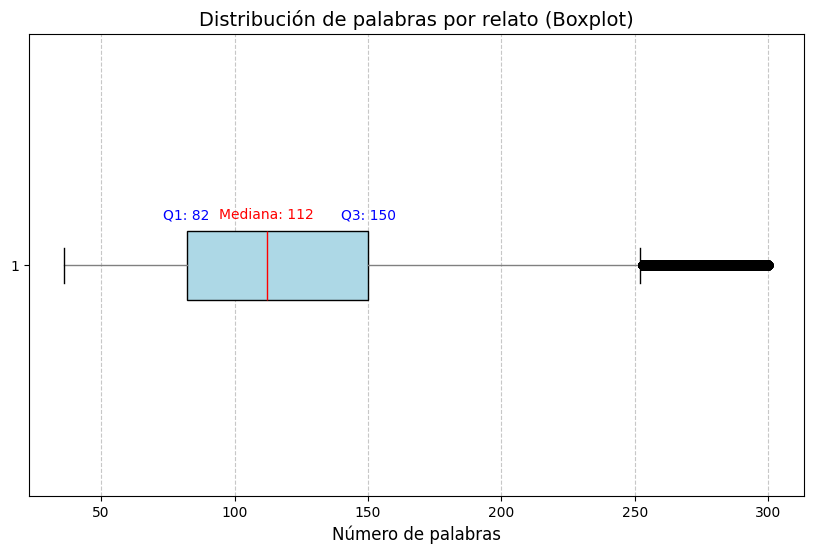

In [13]:
plt.figure(figsize=(10, 6))
plt.boxplot(
    word_counts,
    vert=False,  # Orientación horizontal
    patch_artist=True,
    boxprops=dict(facecolor="lightblue"),  # Personalización
    whiskerprops=dict(color="gray"),
    medianprops=dict(color="red"),
)

plt.title("Distribución de palabras por relato (Boxplot)", fontsize=14)
plt.xlabel("Número de palabras", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Opcional: Añadir anotaciones de percentiles
percentiles = np.percentile(word_counts, [25, 50, 75])
plt.text(percentiles[0], 1.1, f"Q1: {percentiles[0]:.0f}", ha="center", color="blue")
plt.text(percentiles[1], 1.1, f"Mediana: {percentiles[1]:.0f}", ha="center", color="red")
plt.text(percentiles[2], 1.1, f"Q3: {percentiles[2]:.0f}", ha="center", color="blue")

plt.show()

## Using Generative AI to create question dataset

1. It seems that it could be a good practice use only samples from more than 100 words. Maybe it could be interesting to consider $82 \leq w \leq150$
2. After that let us try to use some models to get some questions in the format

`{'question':{}, 'answer':{}, 'context':{}}`

In [14]:
# Usar procesamiento por lotes (batched) para mayor velocidad
filtered_ds = ds["train"].filter(
    lambda batch: [82 <= x <= 150 for x in batch["word_count"]], # Apply the condition to each element in the batch
    batched=True,  # Procesa en chunks
    batch_size=1000  # Ajusta según tu RAM
)
filtered_ds

Filter:   0%|          | 0/341669 [00:00<?, ? examples/s]

Dataset({
    features: ['relato', 'labels', 'word_count'],
    num_rows: 174594
})

In [15]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

def generate_qa_with_context(text):
    input_text = f"Generate 3 questions and answers based on: {text}"
    inputs = tokenizer(input_text, return_tensors="pt", max_length=512, truncation=True)
    outputs = model.generate(**inputs, max_length=200)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Ejemplo
result = generate_qa_with_context(ds['train']['relato'][100])
print(result)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

What was the name of the person who threw the money?


In [20]:
text_eng = """It is the case, Mr. Prosecutor, that on August 17, 2018, at approximately 11:00 AM, I left my residence located in the 8 de marzo cooperative, street n, passage e20j, lot 3, number s8 45, sector puente dos, general rumiñahui highway to carry out some payment errands. Upon returning at 1:20 PM, I observed that three individuals were leaving my residence, and outside there was a car parked. Upon entering, I realized that they had taken two LG 4K 65-inch televisions, a Samsung HD 32-inch television, a PlayStation Pro 1TB, a Nintendo Switch, four whiskies, a lot of silver and gold jewelry valued at $3,450 and $40 in cash, for which I am filing this report with the purpose of conducting an investigation of the case. For more information, contact 2605431, 0984860935."""
result = generate_qa_with_context(text_eng)
pprint(result)

'What was the value of the whiskies?'


In [16]:
from transformers import pipeline

# Cargar el modelo y tokenizer
qa_generator = pipeline(
    "text2text-generation",
    model="mrm8488/t5-base-finetuned-question-generation-ap",
    tokenizer="mrm8488/t5-base-finetuned-question-generation-ap"
)

# Función para generar preguntas
def generate_qa(text, max_length=512):
    input_text = f"generate questions: {text}"
    results = qa_generator(
        input_text,
        max_length=max_length,
        num_return_sequences=3,  # Número de preguntas a generar
        num_beams=5,
        temperature=0.7
    )
    return [result["generated_text"] for result in results]

# Ejemplo con tu relato
text = ds["train"][100]["relato"]
questions = generate_qa(text)
print("Preguntas generadas:", questions)

config.json:   0%|          | 0.00/1.23k [00:00<?, ?B/s]

The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.


model.safetensors:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.


spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.79k [00:00<?, ?B/s]

The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
Device set to use cuda:0
/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based gene

Preguntas generadas: ['question: En el caso seor fiscal que el da 17 de agosto del 2018 aproximadamente a las 11h00 sal de mi domicilio n pasaje e20j lote 3 nmero s8 45 sector puente dos autopista general rumiahui a realizar una gestión de pagos al retornar a las 13h', 'question: En el caso seor fiscal que el da 17 de agosto del 2018 aproximadamente a las 11h00 sal de mi domicilio ubicado en la cooperativa 8 de marzo calle n pasaje e20j lote 3 nmero s8 45 sector puente dos autopista general rumiahui a realizar una gesti', 'question: En el caso seor fiscal que el da 17 de agosto del 2018 aproximadamente a las 11h00 sal de mi domicilio y afuera ase encontraron una gestión de pagos al retornar a las 13h20 puente dos autopista general rumiahui a realizar una gestión de']


In [17]:
pprint(questions)

['question: En el caso seor fiscal que el da 17 de agosto del 2018 '
 'aproximadamente a las 11h00 sal de mi domicilio n pasaje e20j lote 3 nmero '
 's8 45 sector puente dos autopista general rumiahui a realizar una gestión de '
 'pagos al retornar a las 13h',
 'question: En el caso seor fiscal que el da 17 de agosto del 2018 '
 'aproximadamente a las 11h00 sal de mi domicilio ubicado en la cooperativa 8 '
 'de marzo calle n pasaje e20j lote 3 nmero s8 45 sector puente dos autopista '
 'general rumiahui a realizar una gesti',
 'question: En el caso seor fiscal que el da 17 de agosto del 2018 '
 'aproximadamente a las 11h00 sal de mi domicilio y afuera ase encontraron una '
 'gestión de pagos al retornar a las 13h20 puente dos autopista general '
 'rumiahui a realizar una gestión de']


In [21]:
questions = generate_qa(text_eng)
pprint(questions)

/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(


['question: What is the purpose of this report?',
 'question: What is the purpose of this investigation?',
 'question: What was the purpose of this report?']


- There exist the problem of the language. Models used until now seem more efective in English than in Spanish
- I do not agree in using extractive AI to train extractive AI but let us see what happens

In [22]:
preguntas_comunes = [
    "¿Qué objetos fueron robados?",
    "¿En qué fecha ocurrió el incidente?",
    "¿A qué hora sucedió el hecho?",
    "¿Cuál es la dirección donde ocurrió el incidente?",
    "¿Qué valor tenían los objetos sustraídos?",
    "¿Existió intimidación, agresión o violencia?"
]

In [24]:
from transformers import pipeline

# Cargar modelo y tokenizer en español
qa_pipeline = pipeline(
    "question-answering",
    model="PlanTL-GOB-ES/roberta-large-bne-sqac",  # Modelo oficial del PlanTL
    tokenizer="PlanTL-GOB-ES/roberta-large-bne-sqac"
)

# Función para extraer respuestas
def get_answers(context, questions):
    answers = []
    for question in questions:
        result = qa_pipeline(question=question, context=context)
        answers.append({
            "pregunta": question,
            "respuesta": result["answer"],
            "score": round(result["score"], 3)
        })
    return answers

# Ejemplo con tu relato
context = ds["train"][100]["relato"]
respuestas = get_answers(context, preguntas_comunes)

# Imprimir resultados
for respuesta in respuestas:
    pprint(f"Pregunta: {respuesta['pregunta']}")
    pprint(f"Respuesta: {respuesta['respuesta']} (Confianza: {respuesta['score']})\n")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/858k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/516k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.48M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Device set to use cuda:0


'Pregunta: ¿Qué objetos fueron robados?'
'Respuesta: dos (Confianza: 0.147)\n'
'Pregunta: ¿En qué fecha ocurrió el incidente?'
('Respuesta: el día 17 de agosto del 2018 aproximadamente a las 11h00 '
 '(Confianza: 0.26)\n')
'Pregunta: ¿A qué hora sucedió el hecho?'
'Respuesta: aproximadamente a las 11h00 (Confianza: 0.566)\n'
'Pregunta: ¿Cuál es la dirección donde ocurrió el incidente?'
'Respuesta: la cooperativa 8 de marzo (Confianza: 0.026)\n'
'Pregunta: ¿Qué valor tenían los objetos sustraídos?'
('Respuesta: valorado en 3 450 dolares y 40 dólares en efectivo (Confianza: '
 '0.029)\n')
'Pregunta: ¿Existió intimidación, agresión o violencia?'
'Respuesta: sustraído (Confianza: 0.005)\n'


At this point I think what I ought to do is to work with an instruct model and inference from huggingface in order to save some processing. There I could define the type of output I would want, the model and some other parameters. It is necessary to use a spanish based model or consider translation

### DeepSeek Example

In [27]:
from huggingface_hub import InferenceClient

client = InferenceClient(
	api_key=token
)

messages = [
	{
		"role": "user",
		"content": "What is the capital of France?"
	}
]

completion = client.chat.completions.create(
    model="deepseek-ai/DeepSeek-R1",
	messages=messages,
	max_tokens=500
)

print(completion.choices[0].message)

HfHubHTTPError: (Request ID: w-KLJU)

403 Forbidden: None.
Cannot access content at: https://api-inference.huggingface.co/models/deepseek-ai/DeepSeek-R1/v1/chat/completions.
Make sure your token has the correct permissions.
The model deepseek-ai/DeepSeek-R1 is too large to be loaded automatically (688GB > 10GB).